# ADCP Quality Flagging

Quality flagging of raw data. Only previous processing is removal of data before deployment and adding transducer's height.

Following the IOD Quality Flag Standard.

In [12]:
from mhkit import dolfyn
import xarray as xr
import my_functions as my
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# loading raw data
ds = dolfyn.load('A0524000_raw.nc')
ds

<xarray.Dataset> Size: 13MB
Dimensions:              (time: 16672, dir: 4, range: 24, beam: 4, x1: 4,
                          x2: 4, earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 133kB 2024-05-15T12:00:00 ... ...
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * range                (range) float32 96B 3.52 4.52 5.52 ... 25.52 26.52
  * beam                 (beam) int32 16B 1 2 3 4
  * x1                   (x1) int64 32B 1 2 3 4
  * x2                   (x2) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/21)
    number               (time) uint32 67kB 193 194 195 ... 16862 16863 16864
    builtin_test_fail    (time) bool 17kB False False False ... False False
    c_sound              (time) float32 67kB 1.507e+03 1.507e+03 ... 1.518e+03
    depth                (time) float32 67kB 22.36 22.36 22.26 ... 23.56 23.66
    pitch                (time) float32 67kB -6.44 -6.44 -6.45 ... -6.7 -6.68
    roll                 (time) float32 67kB -1.2 -1.22 -1.22 ... -1.28 -1.28
    ...                   ...
    vel                  (dir, range, time) float32 6MB 0.2 0.185 ... nan nan
    amp                  (beam, range, time) uint8 2MB 141 142 143 ... 122 118
    corr                 (beam, range, time) uint8 2MB 123 124 123 ... 104 105
    prcnt_gd             (beam, range, time) uint8 2MB 0 0 0 0 0 0 ... 0 0 0 0 0
    beam2inst_orientmat  (x1, x2) float32 64B 1.462 -1.462 0.0 ... -1.034 -1.034
    orientmat            (earth, inst, time) float32 600kB 0.3437 ... -0.993
Attributes: (12/38)
    firmware_ver:             50.4
    inst_make:                TRDI
    inst_type:                ADCP
    rotate_vars:              ['vel']
    has_imu:                  0
    inst_model:               Workhorse
    ...                       ...
    transmit_lag_m:           0.25
    bandwidth:                0
    power_level:              255
    serialnum:                21788
    range_offset:             1.4
    fs:                       0.0011363636363636363

### Define parameters of the specific dataset

In [14]:
# For mask of unrealistic temperature values
T_min=0  # [degree celsius]
T_max=35 # [degree celsius]

# For mask of clock drift
ensamble_interval_min = 15 # [min]
ensamble_interval = np.timedelta64(15*60*10^9, 'ns') # [ns]

# For mask of deployment time wrong
deployment_time = np.datetime64('2024-05-15T12:00:00')

# For mask pressure out of expected interval
depth_expected = 22  # [m]    
tidal_amplitude_expected = 3  # [m]  Corresponds to tidal amplitude 3, slightly higher than actual 

# For mask of compass heading devation
heading_expected = 55 # [degrees] clockwise from north

# For using the correct timezome
wintertime = False  # Data is currently in summertime

### Adding quality flags to variables

Numeric flagging arrays are created for corresponding variable, then saved as ancillary variables.

The flagging system includes a primary flag indicating the quality and a secondary flag with a description.

#### Quality flagging temperature

In [15]:
# Creating flagging arrays, default values are (2,2) indicating unknown quality
temp_qc1 = xr.full_like(ds['temp'], 2)        # primary quality flags
temp_qc2 = xr.full_like(ds['temp'], 2)        # secondary quality flags

# Create masks 
# Mask NaNs
mask_NaN_temp = np.isnan(ds['temp'])

# Mask unrealistic temperature values
mask_temp_unrealistic = (ds['temp'] <= T_min) |(ds['temp'] >= T_max)

# Mask temperature spikes
mask_temp_spikes = my.detect_spikes(ds['temp'],window=192, dim='time', min_periods=3, threshold=4)

# Mask passed all test
mask_temp_passed = (
    ~mask_temp_unrealistic &
    ~mask_temp_spikes &
    ~mask_NaN_temp
    )

# Apply masks to corresponding values to flagging arrays
temp_qc1, temp_qc2 = my.apply_qc_mask(mask_temp_spikes, (4, 4), temp_qc1, temp_qc2)
temp_qc1, temp_qc2 = my.apply_qc_mask(mask_temp_unrealistic, (4, 5), temp_qc1, temp_qc2)
temp_qc1, temp_qc2 = my.apply_qc_mask(mask_NaN_temp, (9, 3), temp_qc1, temp_qc2)
temp_qc1, temp_qc2 = my.apply_qc_mask(mask_temp_passed, (1, 1), temp_qc1, temp_qc2)

# Add the numeric QC flags
ds['temp_qc_primary'] = temp_qc1.assign_attrs({
    'long_name': 'Quality flags for temperature (primary level)',
    'flag_values': [1, 2, 3, 4, 9],    
    'flag_meanings': 'good unknown potentially_correctable_bad_data bad missing_data',
    'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
})

# Add the descriptive QC flags
ds['temp_qc_secondary'] = temp_qc2.assign_attrs({
        'long_name': 'Quality flag descriptions for temperature (secondary level)',
        'flag_values': [1,2,3,4,5],  
        'flag_meanings':
                'passed_all_tests '
                'unknown '
                'missing_data '
                'temperature_spike '
                'unrealistic_temperature ',
        'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
    })

# Link as ancillary variables
ds['temp'].attrs['ancillary_variables'] = 'temp_qc_primary temp_qc_secondary'

my.summarize_qc(ds, 'temp_qc_primary')
my.summarize_qc(ds, 'temp_qc_secondary')

QC Summary for 'temp_qc_primary':
good: 16670 (99.99%)
unknown: 0 (0.00%)
potentially_correctable_bad_data: 0 (0.00%)
bad: 2 (0.01%)
missing_data: 0 (0.00%)


QC Summary for 'temp_qc_secondary':
passed_all_tests: 16670 (99.99%)
unknown: 0 (0.00%)
missing_data: 0 (0.00%)
temperature_spike: 2 (0.01%)
unrealistic_temperature: 0 (0.00%)




#### Quality flagging time

In [16]:
# Creating flagging arrays, default values are (2,2) indicating unknown quality
time_qc1 = xr.full_like(ds['time'], 2, dtype=int)        # primary quality flags
time_qc2 = xr.full_like(ds['time'], 2, dtype=int)        # secondary quality flags

# Create masks 
# Mask NaNs
mask_NaN_time = np.isnan(ds['time']).astype(bool)

# Mask clock drift
time_diff = np.abs(ds['time'] - ds['time'].shift(time=1)).fillna(ensamble_interval)
# mask where time difference is not following set ensamble interval
mask_clock_drift = ~(time_diff == ensamble_interval)

# Mask deployment time wrong
start_time_ds = ds['time'].isel(time=0)

if deployment_time == start_time_ds:
    mask_time_wrong = xr.full_like(ds['time'], False, dtype=bool)
else:
    mask_time_wrong = xr.full_like(ds['time'], True, dtype=bool)

# Mask passed all tests
mask_time_passed = (
    ~mask_clock_drift &
    ~mask_time_wrong &
    ~mask_NaN_time
)

# Apply masks to corresponding values to flagging arrays

time_qc1, time_qc2 = my.apply_qc_mask(mask_NaN_time, (9, 3), time_qc1, time_qc2)
time_qc1, time_qc2 = my.apply_qc_mask(mask_time_wrong, (3, 5), time_qc1, time_qc2)
time_qc1, time_qc2 = my.apply_qc_mask(mask_clock_drift, (3, 4), time_qc1, time_qc2)
time_qc1, time_qc2 = my.apply_qc_mask(mask_time_passed, (1, 1), time_qc1, time_qc2)

# Add the numeric QC flags
ds['time_qc_primary'] = time_qc1.assign_attrs({
    'long_name': 'Quality flags for time (primary level)',
    'flag_values': [1, 2, 3, 4, 9],
    'flag_meanings': 'good unknown potentially_correctable_bad_data bad missing_data',
    'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
})

# Add the descriptive QC flags
ds['time_qc_secondary'] = time_qc2.assign_attrs({
    'long_name': 'Quality flag descriptions for time (secondary level)',
    'flag_values': [1, 2, 3, 4, 5],
    'flag_meanings':
        'passed_all_tests '
        'unknown '
        'missing_data '
        'clock_drift '
        'deployment_time_wrong ',
    'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
})

# Link as ancillary variables
ds['time'].attrs['ancillary_variables'] = 'time_qc_primary time_qc_secondary'

my.summarize_qc(ds, 'time_qc_primary')
my.summarize_qc(ds, 'time_qc_secondary')

QC Summary for 'time_qc_primary':
good: 1 (0.01%)
unknown: 0 (0.00%)
potentially_correctable_bad_data: 16671 (99.99%)
bad: 0 (0.00%)
missing_data: 0 (0.00%)


QC Summary for 'time_qc_secondary':
passed_all_tests: 1 (0.01%)
unknown: 0 (0.00%)
missing_data: 0 (0.00%)
clock_drift: 16671 (99.99%)
deployment_time_wrong: 0 (0.00%)




#### Quality flagging pressure

In [17]:
# Creating flagging arrays, default values are (2,2) indicating unknown quality
pressure_qc1 = xr.full_like(ds['pressure'], 2, dtype=int)        # primary quality flags
pressure_qc2 = xr.full_like(ds['pressure'], 2, dtype=int)        # secondary quality flags

# Creats masks
# Mask NaNs
mask_NaN_pressure = np.isnan(ds['pressure'])

# Mask pressure drift
# Cumulative deviation test
change_point, test_statistic, S = my.cusum_test(ds['pressure'])
before_change = ds.isel(time=slice(0,change_point))
after_change = ds.isel(time=slice(change_point,-1))

# Apply linear regression before and after potential change
results_before = before_change["pressure"].polyfit(dim='time', deg=1)
slope_before = results_before.polyfit_coefficients.sel(degree=1)
results_after = after_change["pressure"].polyfit(dim='time', deg=1)
slope_after = results_after.polyfit_coefficients.sel(degree=1)

# Compute threshold slope
ns_per_month = 30 * 24 * 60 * 60 * 1e9
slope_tresh = 0.1/(ns_per_month) # corresponds to 0.1 dbar increase per month

mask_pressure_drift = xr.full_like(ds['pressure'], False, dtype=bool)
if abs(slope_before.values) >= slope_tresh:
    mask_pressure_drift[:change_point] = True
elif abs(slope_after.values) >= slope_tresh:
    mask_pressure_drift[change_point:] = True

# Mask constant values
pressure_diff_thresh = 0.001 # allow for rounded values of last digit
mask_pressure_constant = my.detect_const_pressure(ds, pressure_diff_thresh) # Detects three consecutive constant values

# Mask outside expected interval
mask_pressure_deviation = (
    (ds['pressure'] > depth_expected + tidal_amplitude_expected) |
    (ds['pressure'] < depth_expected - tidal_amplitude_expected)
)

# Mask passed all tests
mask_pressure_passed = (
    ~mask_pressure_drift &
    ~mask_pressure_constant &
    ~mask_pressure_deviation &
    ~mask_NaN_pressure
)

# Apply masks to corresponding values to flagging arrays
pressure_qc1, pressure_qc2 = my.apply_qc_mask(mask_pressure_drift, (3, 4), pressure_qc1, pressure_qc2)
pressure_qc1, pressure_qc2 = my.apply_qc_mask(mask_pressure_constant, (4, 5), pressure_qc1, pressure_qc2)
pressure_qc1, pressure_qc2 = my.apply_qc_mask(mask_pressure_deviation, (4, 6), pressure_qc1, pressure_qc2)
pressure_qc1, pressure_qc2 = my.apply_qc_mask(mask_NaN_pressure, (9, 3), pressure_qc1, pressure_qc2)
pressure_qc1, pressure_qc2 = my.apply_qc_mask(mask_pressure_passed, (1, 1), pressure_qc1, pressure_qc2)

# Add the numeric QC flags
ds['pressure_qc_primary'] = pressure_qc1.assign_attrs({
    'long_name': 'Quality flags for pressure (primary level)',
    'flag_values': [1, 2, 3, 4, 9],
    'flag_meanings': 'good unknown potentially_correctable_bad_data bad missing_data',
    'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
})

# Add the descriptive QC flags
ds['pressure_qc_secondary'] = pressure_qc2.assign_attrs({
    'long_name': 'Quality flag descriptions for pressure (secondary level)',
    'flag_values': [1, 2, 3, 4, 5, 6],
    'flag_meanings':
        'passed_all_tests '
        'unknown '
        'missing_data '
        'pressure_drift '
        'constant_pressure '
        'pressure_outside_expected_interval ',
    'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
})

# Link as ancillary variables
ds['pressure'].attrs['ancillary_variables'] = 'pressure_qc_primary pressure_qc_secondary'

my.summarize_qc(ds, 'pressure_qc_primary')
my.summarize_qc(ds, 'pressure_qc_secondary')

QC Summary for 'pressure_qc_primary':
good: 16672 (100.00%)
unknown: 0 (0.00%)
potentially_correctable_bad_data: 0 (0.00%)
bad: 0 (0.00%)
missing_data: 0 (0.00%)


QC Summary for 'pressure_qc_secondary':
passed_all_tests: 16672 (100.00%)
unknown: 0 (0.00%)
missing_data: 0 (0.00%)
pressure_drift: 0 (0.00%)
constant_pressure: 0 (0.00%)
pressure_outside_expected_interval: 0 (0.00%)




Change point detected at index: 11048, corresponding to time 2024-09-07T14:00:00.000000000


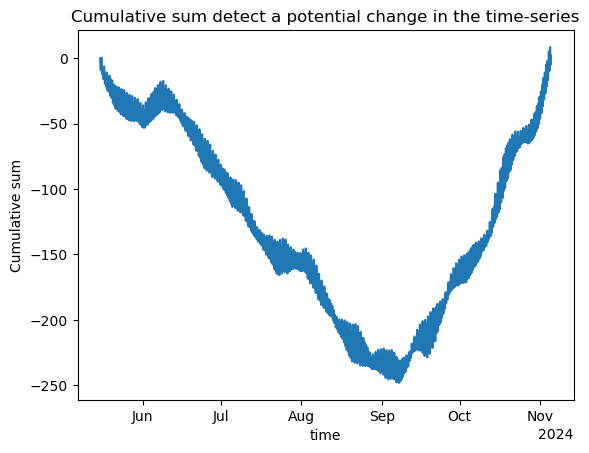

slope of regression before change: -3.408575625664439e-19
slope of regression after change: 5.9637025618217885e-18
slope of threshold of 0.1 dbar/month: 3.858024691358025e-17


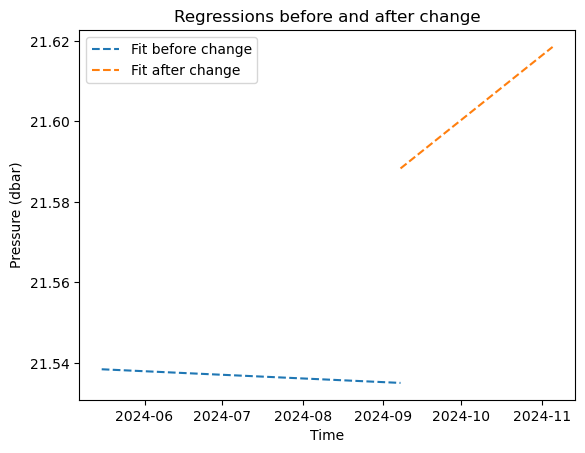

In [18]:
# Summary of pressure drift

print(f"Change point detected at index: {change_point}, corresponding to time {ds["time"][change_point].values}")
S.plot()
plt.ylabel('Cumulative sum')
plt.title('Cumulative sum detect a potential change in the time-series')
plt.show()

print(f"slope of regression before change: {slope_before.values}")
print(f"slope of regression after change: {slope_after.values}")
print(f"slope of threshold of 0.1 dbar/month: {slope_tresh}")

fit_before = xr.polyval(before_change["time"], results_before.polyfit_coefficients)
fit_after = xr.polyval(after_change["time"], results_after.polyfit_coefficients)

# Plot
plt.plot(before_change["time"], fit_before, '--', label="Fit before change")
plt.plot(after_change["time"], fit_after, '--', label="Fit after change")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Pressure (dbar)")
plt.title("Regressions before and after change")
plt.show()

#### Quality flagging compass heading

In [19]:
# Creating flagging arrays, default values are (2,2) indicating unknown quality
heading_qc1 = xr.full_like(ds['heading'], 2, dtype=int)        # primary quality flags
heading_qc2 = xr.full_like(ds['heading'], 2, dtype=int)        # secondary quality flags

# Create masks
# Mask NaNs
mask_NaN_heading = np.isnan(ds['heading'])

# Mask compass heading deviation
heading_thresh = 5
heading_start = ds['heading'].isel(time=0).values
# Calculate absolute angular difference 
heading_diff = ds['heading'] - heading_start
angular_diff = np.abs((heading_diff + 180) % 360 - 180)
# Mask where deviation from start exceeds threshold
mask_heading_deviation = angular_diff > heading_thresh

# Mask compass calibration according to if the principal heading is as expected
vel_avg = ds['vel'].mean(dim='range')
principal_heading = dolfyn.calc_principal_heading(vel_avg)
heading_thresh = 5
mask_compass_wrong = (
    (principal_heading > heading_expected + heading_thresh) |
    (principal_heading < heading_expected - heading_thresh)
)

# Mask passed all tests
mask_heading_passed = (
    ~mask_heading_deviation &
    ~mask_compass_wrong &
    ~mask_NaN_heading
)

# Apply masks to corresponding values to flagging arrays
heading_qc1, heading_qc2 = my.apply_qc_mask(mask_compass_wrong, (3, 5), heading_qc1, heading_qc2)
heading_qc1, heading_qc2 = my.apply_qc_mask(mask_heading_deviation, (3, 4), heading_qc1, heading_qc2)
heading_qc1, heading_qc2 = my.apply_qc_mask(mask_NaN_heading, (9, 3), heading_qc1, heading_qc2)
heading_qc1, heading_qc2 = my.apply_qc_mask(mask_heading_passed, (1, 1), heading_qc1, heading_qc2)

# Add the numeric QC flags
ds['heading_qc_primary'] = heading_qc1.assign_attrs({
    'long_name': 'Quality flags for heading (primary level)',
    'flag_values': [1, 2, 3, 4, 9],
    'flag_meanings': 'good unknown potentially_correctable_bad_data bad missing_data',
    'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
})

# Add the descriptive QC flags
ds['heading_qc_secondary'] = heading_qc2.assign_attrs({
    'long_name': 'Quality flag descriptions for heading (secondary level)',
    'flag_values': [1, 2, 3, 4, 5],
    'flag_meanings':
        'passed_all_tests '
        'unknown '
        'missing_data '
        'compass_heading_deviation '
        'compass_calibration_wrong ',
    'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
})

# Link as ancillary variables
ds['heading'].attrs['ancillary_variables'] = 'heading_qc_primary heading_qc_secondary'

my.summarize_qc(ds, 'heading_qc_primary')
my.summarize_qc(ds, 'heading_qc_secondary')

QC Summary for 'heading_qc_primary':
good: 16672 (100.00%)
unknown: 0 (0.00%)
potentially_correctable_bad_data: 0 (0.00%)
bad: 0 (0.00%)
missing_data: 0 (0.00%)


QC Summary for 'heading_qc_secondary':
passed_all_tests: 16672 (100.00%)
unknown: 0 (0.00%)
missing_data: 0 (0.00%)
compass_heading_deviation: 0 (0.00%)
compass_calibration_wrong: 0 (0.00%)




#### Quality flagging velocity

In [20]:
# Creating flagging arrays, default values are (2,2) indicating unknown quality
qc1 = xr.full_like(ds['vel'], 2)        # primary quality flags
qc2 = xr.full_like(ds['vel'], 2)        # secondary quality flags

# Create masks 
# values above surface, True where range > depth
mask_above_surface = ds['range'] > ds['depth']   

# values contaminated from surface interference (upper 15%)
mask_surface_interference = (ds['range']/ds['depth'] >= 0.85) & (ds['range']/ds['depth'] <= 1)

# values below correlation threshold
corr_threshold = 64
mask_below_corr_thresh = (ds['corr'] <= corr_threshold).any(dim='beam')

# amplitude outliers
bottom_threshold = 225
surface_threshold = 100
mask_outlier = (~my.detect_outliers(ds, bottom_threshold, surface_threshold, set_to_NaN=False))

# NaN values
mask_NaN = np.isnan(ds['vel'])

# compass error
compass_error = (mask_heading_deviation | mask_compass_wrong)

# Mask due to pressure errors within tidal range
pressure_error = (mask_pressure_deviation | mask_pressure_constant | mask_pressure_drift)
count_false = (~pressure_error).sum()

if count_false > 3000:  # want at least 1 months of valid values
    ds_valid_vel = ds.where(~pressure_error, drop=True) # base tidal range on valid values
    HT_max = ds_valid_vel['depth'].max()
    LT_min = ds_valid_vel['depth'].min()
else:
    HT_max = ds['depth'].max()
    LT_min = ds['depth'].min()


mask_pressure_failure = (
    (ds['range'] >= LT_min) &
    (ds['range'] <= HT_max) &
    pressure_error
)

# time error
time_error = (mask_clock_drift | mask_time_wrong)

# Mask velocity spikes
mask_vel_spikes = my.detect_spikes(ds['vel'], window=192, dim='time', min_periods=3, threshold=3)

# passed all checks
mask_passed = (
    ~mask_above_surface
    & ~mask_surface_interference
    & ~mask_below_corr_thresh
    & ~mask_outlier
    & ~mask_NaN
    & ~compass_error
    & ~pressure_error
    & ~time_error
    & ~mask_vel_spikes
    )
    
masks = {
'above_surface': mask_above_surface,
'surface_interference': mask_surface_interference,
'below_corr_thresh': mask_below_corr_thresh,
'outlier': mask_outlier,
'velocity_spike': mask_vel_spikes,
'compass_failure': compass_error,
'pressure_failure': pressure_error,
'time_failure': time_error,
'NaN': mask_NaN,
'passed': mask_passed
}

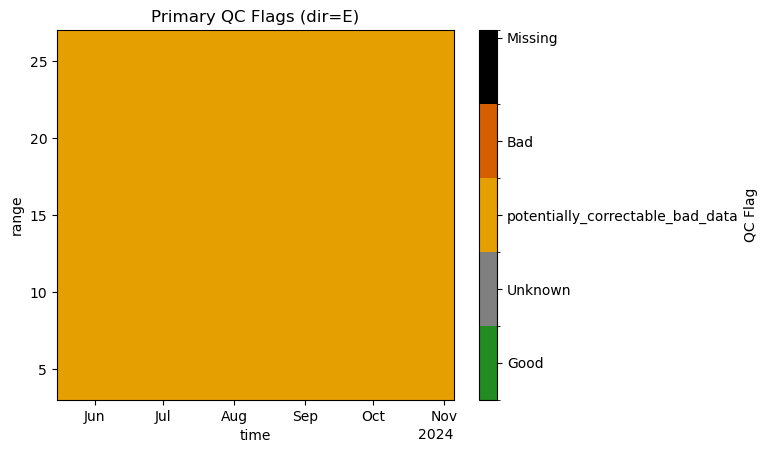

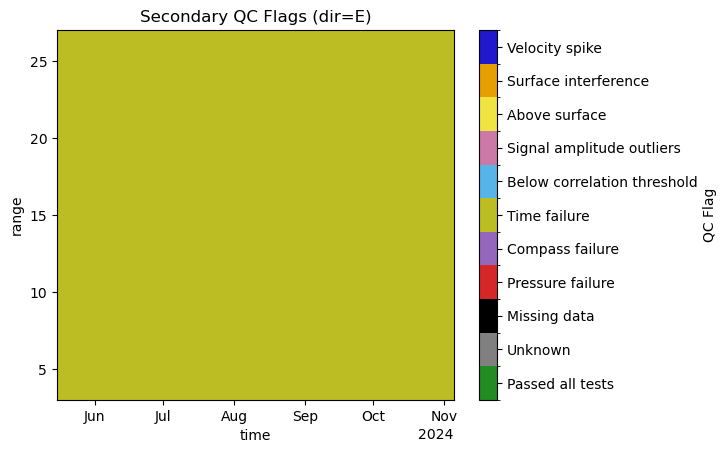

QC Summary for 'vel_qc_primary':
good: 57 (0.00%)
unknown: 0 (0.00%)
potentially_correctable_bad_data: 1600416 (99.99%)
bad: 39 (0.00%)
missing_data: 0 (0.00%)


QC Summary for 'vel_qc_secondary':
passed_all_tests: 57 (0.00%)
unknown: 0 (0.00%)
missing_data: 0 (0.00%)
pressure_failure: 0 (0.00%)
compass_failure: 0 (0.00%)
time_failure: 1600416 (99.99%)
below_correlation_threshold_64: 0 (0.00%)
signal_amplitude_outliers: 0 (0.00%)
above_surface: 20 (0.00%)
surface_interference: 12 (0.00%)
velocity_spike: 7 (0.00%)




In [21]:
# Apply masks to corresponding values to flagging arrays
qc1, qc2 = my.apply_qc_mask(masks['velocity_spike'], (4, 11), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['below_corr_thresh'], (4, 7), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['outlier'], (4, 8), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['NaN'], (9, 3), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['passed'], (1, 1), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['surface_interference'], (4, 10), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['above_surface'], (4, 9), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['compass_failure'], (3, 5), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['pressure_failure'], (3, 4), qc1, qc2)
qc1, qc2 = my.apply_qc_mask(masks['time_failure'], (3, 6), qc1, qc2)


qc1 = qc1.transpose('dir', 'range', 'time')
qc2 = qc2.transpose('dir', 'range', 'time')

# Add the numeric QC flags
ds['vel_qc_primary'] = qc1.assign_attrs({
    'long_name': 'Quality flags for variable (primary level)',
    'flag_values': [1, 2, 3, 4, 9],    
    'flag_meanings': 'good unknown potentially_correctable_bad_data bad missing_data',
    'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
})

# Add the descriptive QC flags
ds['vel_qc_secondary'] = qc2.assign_attrs({
        'long_name': 'Quality flag descriptions for variable (secondary level)',
        'flag_values': [1,2,3,4,5,6,7,8,9,10,11],  
        'flag_meanings':
                'passed_all_tests '
                'unknown '
                'missing_data '
                'pressure_failure '
                'compass_failure '
                'time_failure '
                'below_correlation_threshold_64 '
                'signal_amplitude_outliers '
                'above_surface '
                'surface_interference '
                'velocity_spike ',
        'convention': "Intergovernmental Oceanographic Commission of UNESCO Quality Flag Scheme",
    })

# Link as ancillary variables
ds['vel'].attrs['ancillary_variables'] = 'vel_qc_primary vel_qc_secondary'

my.plot_qc_primary(ds, direction=0)

my.plot_qc_secondary(ds, direction=0) 

my.summarize_qc(ds, 'vel_qc_primary')
my.summarize_qc(ds, 'vel_qc_secondary')

### Adjusting for timezone

In [22]:
# set to summertime if wintertime == False
if wintertime == False:
    ds['time'] = ds['time'] - np.timedelta64(1, 'h')
    wintertime = True

# add attribute timezone : UTC
ds['time'].attrs.update({
    'standard_name': 'time',
    'long_name': 'time of measurement',
    'format': 'YYYY-MM-DDThh:mm:ssZ',
    'timezone': 'UTC',
})

### Save flagged data

In [7]:
dolfyn.save(ds, 'A0524000_flagged.nc')    